This notebook is meant as a sanity check on mixtures of Gaussians.

https://github.com/VincentStimper/normalizing-flows/blob/master/examples/neural_spline_flow.ipynb 

in order to test if using splines is better than realnvp

In [45]:
# Import required packages
import torch
import torch.distributions as td
import copy 
import numpy as np
import normflows as nf\

from matplotlib import pyplot as plt

from tqdm import tqdm

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file
from flonacomldft.sampling import run_metropolis
from flonacomldft.utils.diagnostics import get_ESS
from flonacomldft.models.mixture import Mixture, get_models
from flonacomldft.internal_coordinates import Coordinates_mapping, join_data

from flonacomldft.train_flow_from_data import get_ratio_acc
from flonacomldft.free_energy_computations import (
    compute_TFP_logratio, compute_deepBAR_logratio,
    compute_TFP, compute_BAR
)


def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

# Definiting Gaussian objective


In [46]:
class MoG():
    def __init__(self, means, covars, weights=None,
                 dtype=torch.float32, device='cpu'):
        """
        Class to handle operations around mixtures of multivariate
        Gaussian distributions
        Args:
            means: list of 1d tensors of centroids
            covars: list of 2d tensors of covariances
            weights: list of relative statistical weights (does not need to sum to 1)
        """
        self.device = device
        self.beta = 1.  # model 'temperature' for sampling with langevin and mh
        self.means = means
        self.covars = covars
        self.dim = means[0].shape[0]
        self.k = len(means)  # number of components in the mixture

        if weights is not None:
            self.weights = torch.tensor(weights, dtype=dtype, device=device)
        else:
            self.weights = torch.tensor([1 / self.k] * self.k,
                                        dtype=dtype, device=device)

        self.cs_distrib = td.categorical.Categorical(probs=self.weights)
        self.normal_distribs = []
        for c in range(self.k):
            c_distrib = td.multivariate_normal.MultivariateNormal(
                self.means[c].to(device),
                covariance_matrix=self.covars[c].to(device)
                )
            self.normal_distribs.append(c_distrib)

        self.covars_inv = torch.stack([torch.inverse(cv) for cv in covars])
        self.dets = torch.stack([torch.det(cv) for cv in covars])

    def sample(self, n):
        cs = self.cs_distrib.sample_n(n).to(self.device)

        samples = torch.zeros((n, self.dim), device=self.device)
        for c in range(self.k):
            n_c = (cs == c).sum()
            samples[cs == c, :] = self.normal_distribs[c].sample_n(n_c)
        return samples.to(self.device)

    def log_prob(self, x):
        x = x.unsqueeze(1)
        m = torch.stack(self.means).unsqueeze(0)
        args = - 0.5 * torch.einsum('kci,cij,kcj->kc', x-m, self.covars_inv, x-m)
        args += torch.log(self.weights)
        args -= torch.log((self.weights.sum() * torch.sqrt((2 * np.pi) ** self.dim * self.dets)))
        return  torch.logsumexp(args, 1)

sep = 2.
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2)] #,  2e-2 * torch.eye(2)]
shift_means = [torch.tensor([-sep*0.8, 0])] #, torch.tensor([sep, 0])]

target = MoG(means, covars)
prop = MoG(shift_means, covars)

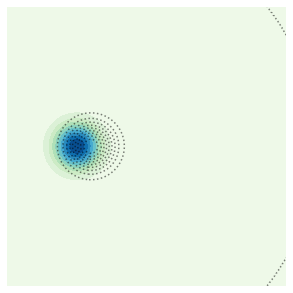

In [47]:
lims = {'x_min':-2 * sep, 'x_max':2 * sep, 'y_min':-2 * sep, 'y_max':2 * sep}
device = 'cpu'

def set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=prop.log_prob, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    plt.axis('off')

    plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 10, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 10, colors='k', linestyles=':', alpha=0.5)


plt.figure(figsize=(5,7))
# plt.suptitle()
ax = plt.subplot(1,1,1)
set_plot(ax)

In [48]:
def run_metropolis_rqs(model,
    x_init,
    n_chains,
    n_steps,
    target_logprob,
    with_tqdm=False,
):
    assert x_init.shape[0] == n_chains

    beta = 1

    xs = []
    us = []
    accs = []
    ratios = []
    nlls = []

    u_init = - target_logprob(x_init).squeeze().float()

    pbar = tqdm(range(n_steps))

    for dt in pbar:
        if isinstance(model, MoG):
            x_new = model.sample(n_chains)
        else:
            x_new, _ = model.sample(n_chains)
        x_new = x_new.clone().detach().float()
        nll_x = - model.log_prob(x_new)
        nll_x_init = - model.log_prob(x_init)
        u_new = - target_logprob(x_new).squeeze().float()

        ratio = -beta * u_new + nll_x
        ratio += beta * u_init - nll_x_init
        ratio = torch.exp(ratio)
        u = torch.rand_like(ratio)
        ratio = torch.min(ratio, torch.ones_like(ratio))
        acc = u < torch.min(ratio, torch.ones_like(ratio))

        x_new[~acc] = x_init[~acc]
        u_new[~acc] = u_init[~acc]

        xs.append(x_new.float().clone())
        us.append(u_new.float().clone())
        accs.append(acc.float().clone())
        nlls.append(nll_x.float().clone())
        ratios.append(ratio.mean().float().clone())

        x_init = x_new.clone().detach()
        u_init = u_new.clone().detach()

        if with_tqdm:
            pbar.set_description(f'acc: {ratio.mean().item() :.2f}')

    return torch.stack(xs), torch.stack(us), torch.stack(accs), torch.stack(nlls), torch.stack(ratios)

In [49]:
mode_label = 0
n_steps = 100
n_chains = 10

mcmc_runs = []

x_init = target.sample(n_chains)
mcmc_run = run_metropolis_rqs(prop, x_init, x_init.shape[0], n_steps, target.log_prob, with_tqdm=True)
mcmc_runs.append(mcmc_run)

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/torch/distributions/distribution.py:161: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)
acc: 0.37: 100%|██████████| 100/100 [00:01<00:00, 89.52it/s]


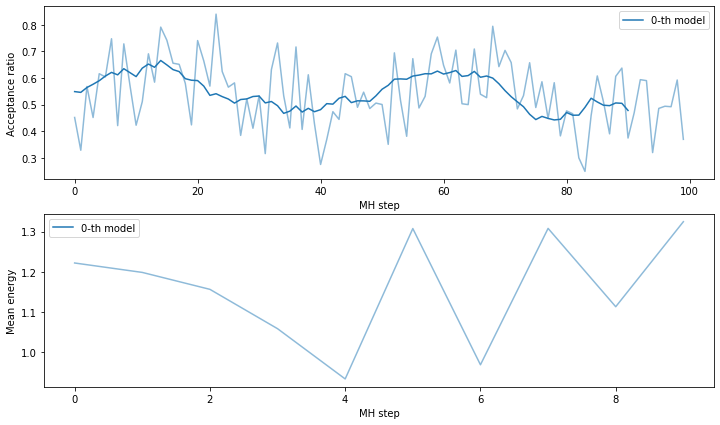

In [50]:
plt.figure(figsize=(12,7))
axes = [plt.subplot(2, 1, i + 1) for i in range(2)]
for m,mcmc_run in enumerate(mcmc_runs):
    
    xs, us, accs, nlls, ratios = mcmc_run
    plt.sca(axes[0])
    _ = plt.plot(ratios.detach().numpy(), alpha=0.5)
    plt.plot(moving_average(ratios.detach().numpy(), 10), c=_[0].get_color(), label='{:d}-th model'.format(2 * m))
    plt.xlabel('MH step')
    plt.ylabel('Acceptance ratio')
    plt.legend(ncol=2)

    plt.sca(axes[1]) 
    _ = plt.plot(us.mean(0).detach().numpy(), alpha=0.5)
    plt.plot(moving_average(us.mean(0).detach().numpy(), 10), c=_[0].get_color(), label='{:d}-th model'.format(2* m))
    plt.xlabel('MH step')
    plt.ylabel('Mean energy')
    plt.legend(ncol=2)

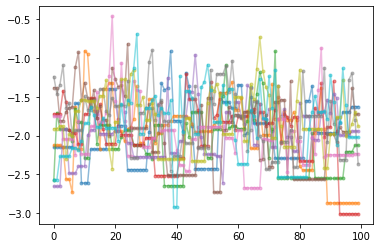

In [51]:
plt.plot(xs[:,:,0].detach().numpy(), '.-', alpha=0.5)


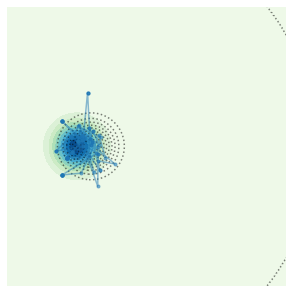

In [52]:

plt.figure(figsize=(5,7))
# plt.suptitle()
ax = plt.subplot(1,1,1)
set_plot(ax)
plt.plot(xs[:,0,0].detach().numpy(), xs[:,0,1].detach().numpy(), '.-', alpha=0.5)

# Training Flows

In [53]:
def get_ratio_acc_rqs(prop, x_init, n_chains, target_logprob):
    
    assert x_init.shape[0] == n_chains

    beta = 1 
    u_init = target_logprob(x_init)

    x_new, _ = prop.sample(n_chains)
    x_new = x_new.clone().detach().float()

    nll_x = - prop.log_prob(x_new)
    nll_x_init = - prop.log_prob(x_init)

    u_new = torch.zeros((n_chains, 1))
    u_new = target_logprob(x_new)
    u_new = u_new.squeeze().float()

    ratio = -beta * u_new + nll_x
    ratio += beta * u_init - nll_x_init
    ratio = torch.exp(ratio)

    return torch.minimum(torch.ones_like(ratio), ratio).detach().cpu().numpy()

In [54]:
# Define flows
# number of blocks
K = 4
torch.manual_seed(0)

latent_size = 2
hidden_units = 128
hidden_layers = 2


flows = []
for i in range(K):
    flows += [nf.flows.AutoregressiveRationalQuadraticSpline(latent_size, hidden_layers, hidden_units)]
    flows += [nf.flows.LULinearPermute(latent_size)]

# Set prior and q0
q0 = nf.distributions.DiagGaussian(2, trainable=False)
    
# Construct flow model
nfm = nf.NormalizingFlow(q0=q0, flows=flows)

# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
nfm = nfm.to(device)

In [55]:
# Train model
max_iter = 200 #00
# num_samples = 2 ** 9
report_split = 10

mode_label = 0

x_train = target.sample(1000)
x_test = target.sample(100)

losses = np.array([])
test_losses = np.array([])
accs = np.array([get_ratio_acc_rqs(nfm, x_test, x_test.shape[0], target.log_prob).mean()])
models = [copy.deepcopy(nfm)]

optimizer = torch.optim.Adam(nfm.parameters(), lr=1e-3, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()

    # Compute loss
    loss = nfm.forward_kld(x_train)
    
    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    # Log loss
    losses = np.append(losses, loss.to('cpu').data.numpy())

    if (it + 1) % int(max_iter / report_split) == 0:
        nfm.eval()
        test_losses = np.append(test_losses, nfm.forward_kld(x_test[:,:12]).to('cpu').data.numpy())
        accs = np.append(accs, get_ratio_acc_rqs(nfm, x_test, x_test.shape[0], target.log_prob).mean())
        models.append(copy.deepcopy(nfm))
        nfm.train()
    
    # Plot learned distribution
    # if (it + 1) % show_iter == 0:
    #     nfm.eval()
    #     log_prob = nfm.log_prob(zz)
    #     nfm.train()
    #     prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
    #     prob[torch.isnan(prob)] = 0

    #     plt.figure(figsize=(15, 15))
    #     plt.pcolormesh(xx, yy, prob.data.numpy())
    #     plt.gca().set_aspect('equal', 'box')
    #     plt.show()


100%|██████████| 200/200 [00:55<00:00,  3.63it/s]


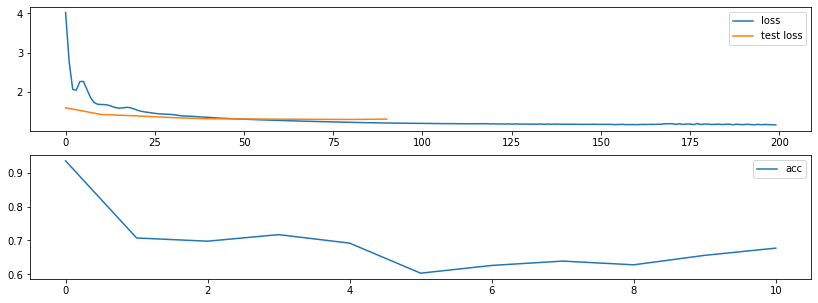

In [56]:
plt.figure(figsize=(14, 5))
axes = [plt.subplot(2, 1, i + 1) for i in range(2)]
plt.sca(axes[0])
plt.plot(losses, label='loss')
plt.plot(np.arange(len(test_losses)) * report_split, test_losses, label='test loss')
plt.legend()

plt.sca(axes[1])
plt.plot(accs, label='acc')
plt.legend()
plt.show()

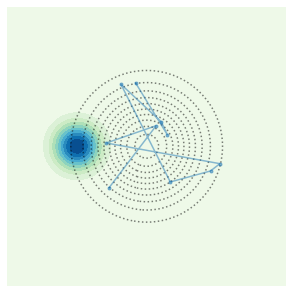

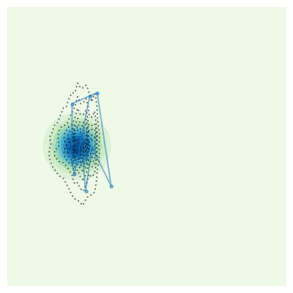

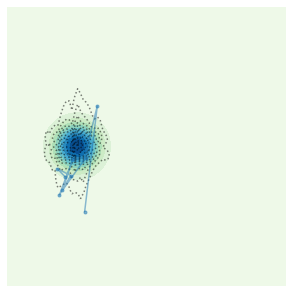

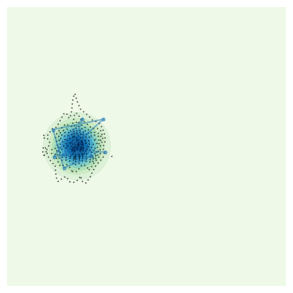

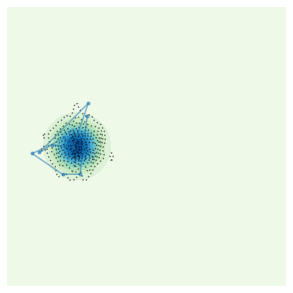

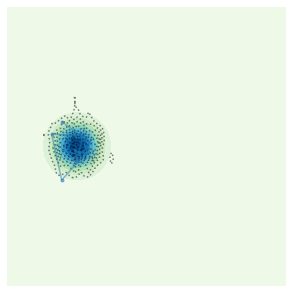

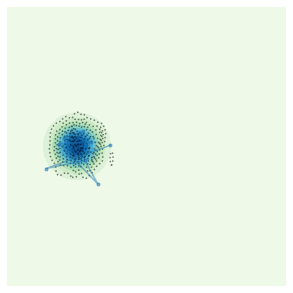

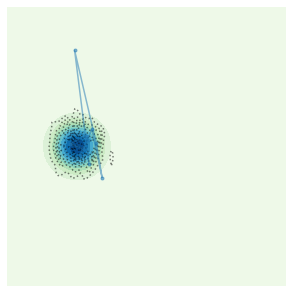

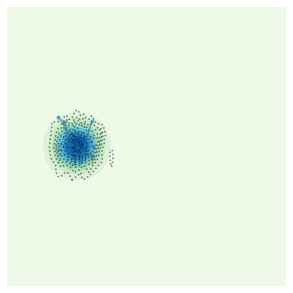

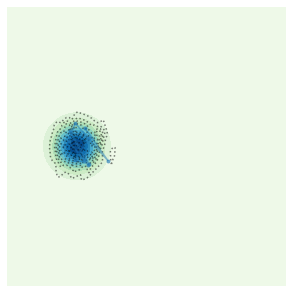

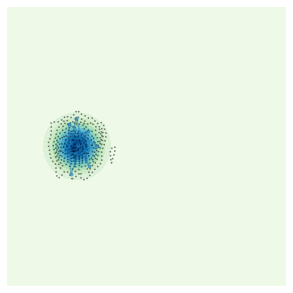

In [57]:
for model in models:
    model.eval()
    plt.figure(figsize=(5,7))
    ax = plt.subplot(1,1,1)
    set_plot(ax, prop_log_prob=model.log_prob, n_points=100)
    samples,_ = model.sample(10)
    plt.plot(samples[:,0].detach().numpy(), samples[:,1].detach().numpy(), '.-', alpha=0.5)
    plt.show()

# Equilibrating the MCMCs

In [58]:
mode_label = 0
n_steps = 100
n_chains = 10

mcmc_runs = []

for model in models:
    model.eval()
    x_init = target.sample(n_chains)
    mcmc_run = run_metropolis_rqs(model, x_init, x_init.shape[0], n_steps, target.log_prob, with_tqdm=True)
    mcmc_runs.append(mcmc_run)

acc: 0.87: 100%|██████████| 100/100 [00:05<00:00, 18.98it/s]


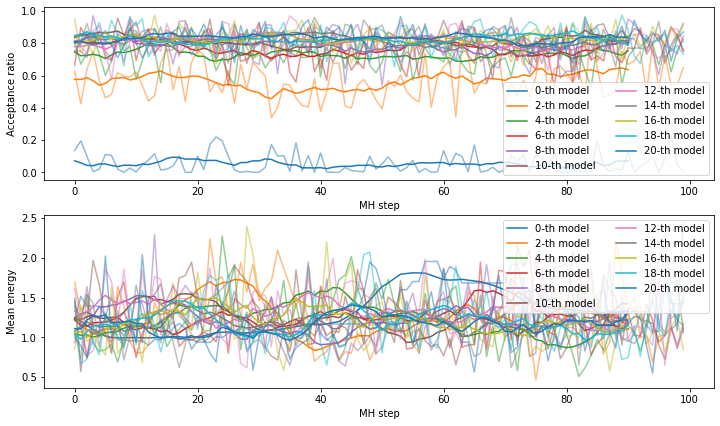

In [59]:
plt.figure(figsize=(12,7))
axes = [plt.subplot(2, 1, i + 1) for i in range(2)]
for m,mcmc_run in enumerate(mcmc_runs):
    
    xs, us, accs, nlls, ratios = mcmc_run
    plt.sca(axes[0])
    _ = plt.plot(ratios.detach().numpy(), alpha=0.5)
    plt.plot(moving_average(ratios.detach().numpy(), 10), c=_[0].get_color(), label='{:d}-th model'.format(2 * m))
    plt.xlabel('MH step')
    plt.ylabel('Acceptance ratio')
    plt.legend(ncol=2)

    plt.sca(axes[1]) 
    _ = plt.plot(us.mean(1).detach().numpy(), alpha=0.5)
    plt.plot(moving_average(us.mean(1).detach().numpy(), 10), c=_[0].get_color(), label='{:d}-th model'.format(2* m))
    plt.xlabel('MH step')
    plt.ylabel('Mean energy')
    plt.legend(ncol=2)


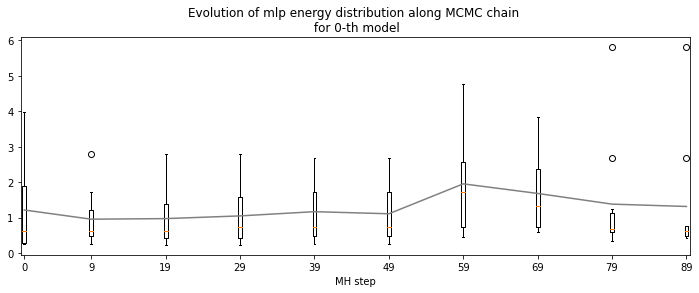

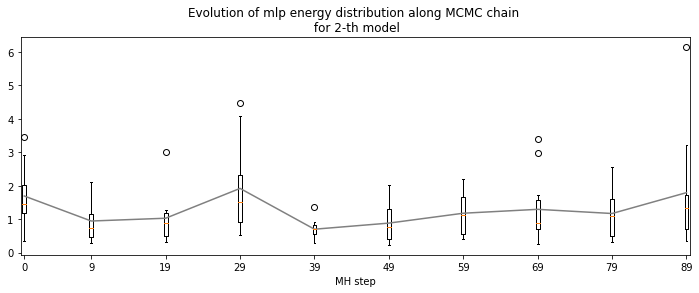

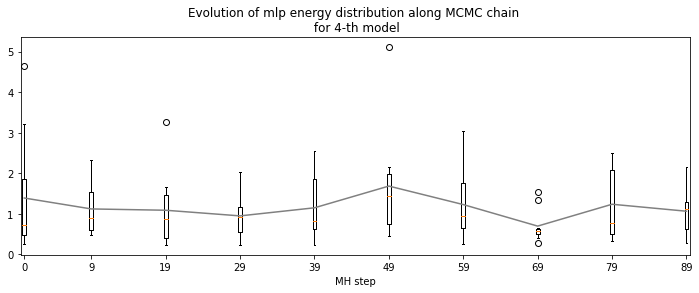

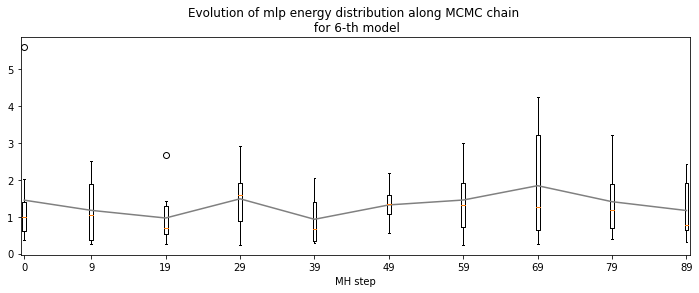

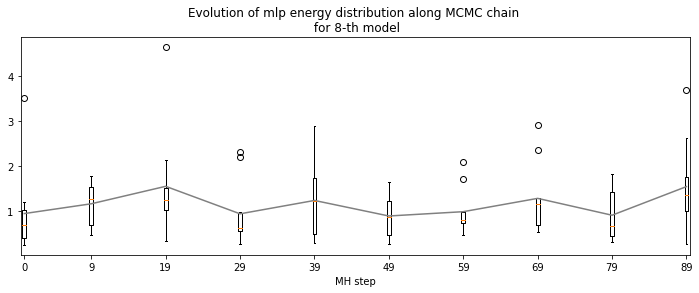

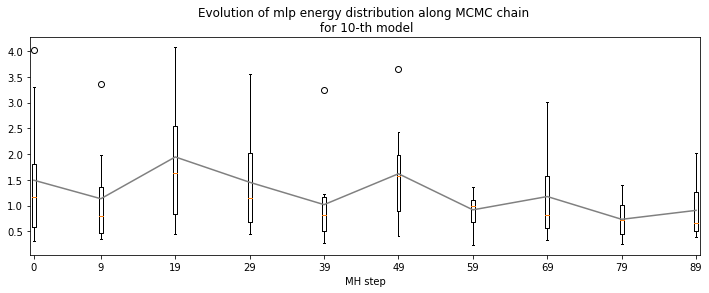

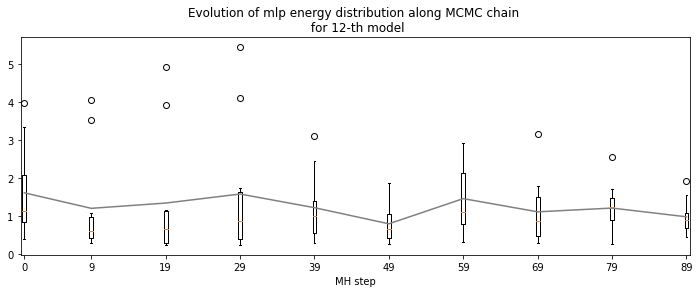

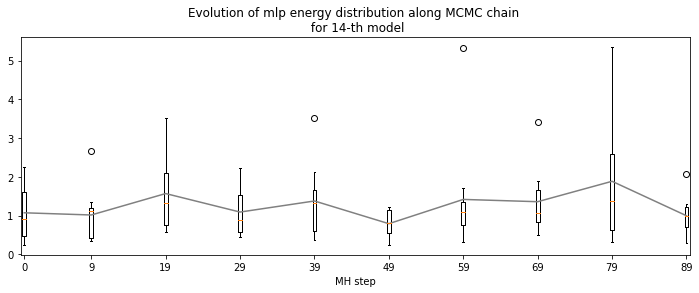

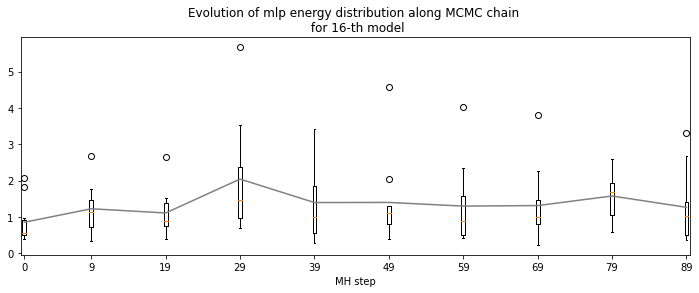

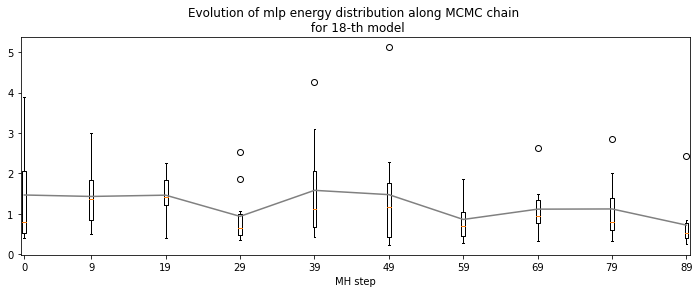

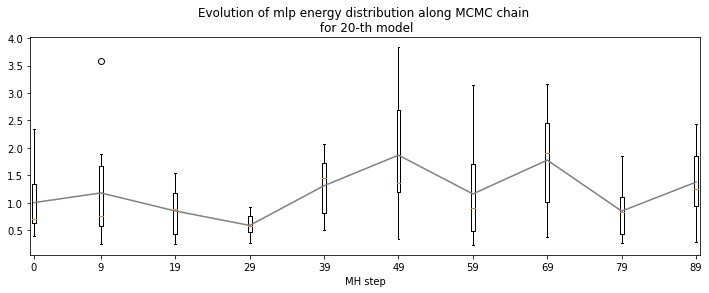

In [60]:
for m,mcmc_run in enumerate(mcmc_runs):
    xs, us, accs, nlls, ratios = mcmc_run
    plt.figure(figsize=(12,4))
    steps = np.maximum(0, np.arange(10) * 10 - 1)
    plt.boxplot([us[step, :].detach().numpy() for step in steps], positions=steps)
    plt.plot(steps, [us[step, :].detach().numpy().mean() for step in steps], '-', c='grey')
    plt.title('Evolution of mlp energy distribution along MCMC chain \n for {:d}-th model'.format(2 * m))
    plt.xlabel('MH step') 

In [61]:
accs_final = []
participation_ratios = []
n_prop = 5000
for (mcmc_run, model) in zip(mcmc_runs, models):
    xs, us, accs, nlls, ratios = mcmc_run
    accs_final.append(moving_average(ratios.detach().numpy(), 20)[-1].mean().item())
    participation_ratios.append(get_participation_ratio_rqs(model, target.log_prob, n_prop).item())

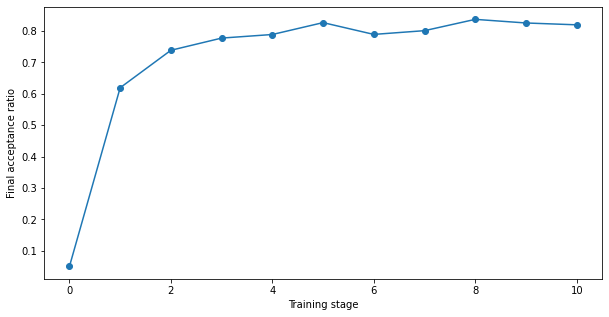

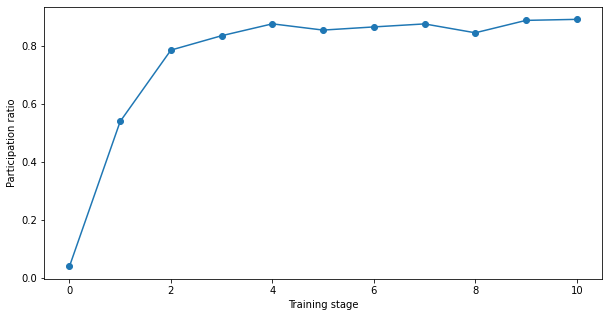

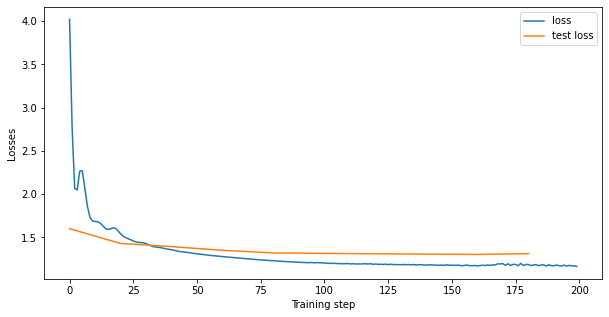

In [62]:

plt.figure(figsize=(10,5))
plt.plot(accs_final, '-o')
plt.xlabel('Training stage')
plt.ylabel('Final acceptance ratio')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(participation_ratios, '-o')
plt.xlabel('Training stage')
plt.ylabel('Participation ratio')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(losses, label='loss')
plt.plot(np.arange(len(test_losses)) * 20, test_losses, label='test loss')
plt.xlabel('Training step')
plt.ylabel('Losses')
plt.legend()

# Gaussians in 12 dimensions

In [18]:
sep = 2.
mean = torch.zeros(12)
mean[0] = sep
means = [mean] #, torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(12)] #,  2e-2 * torch.eye(2)]

shift_mean = torch.zeros(12)
shift_mean[0] = -sep*0.8
shift_means = [torch.tensor([-sep*0.8, 0])] #, torch.tensor([sep, 0])]

target = MoG(means, covars)
prop = MoG(shift_means, covars)

In [19]:
# Define flows
# number of blocks
K = 4
torch.manual_seed(0)

latent_size = 12
hidden_units = 128
hidden_layers = 2


flows = []
for i in range(K):
    flows += [nf.flows.AutoregressiveRationalQuadraticSpline(latent_size, hidden_layers, hidden_units)]
    flows += [nf.flows.LULinearPermute(latent_size)]

# Set prior and q0
q0 = nf.distributions.DiagGaussian(latent_size, trainable=False)
    
# Construct flow model
nfm = nf.NormalizingFlow(q0=q0, flows=flows)

# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
nfm = nfm.to(device)

In [20]:
# Train model
max_iter = 200 #00
# num_samples = 2 ** 9
report_split = 10

mode_label = 0

x_train = target.sample(1000)
x_test = target.sample(100)

losses = np.array([])
test_losses = np.array([])
accs = np.array([get_ratio_acc_rqs(nfm, x_test, x_test.shape[0], target.log_prob).mean()])
models = [copy.deepcopy(nfm)]

optimizer = torch.optim.Adam(nfm.parameters(), lr=1e-3, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()

    # Compute loss
    loss = nfm.forward_kld(x_train)
    
    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    # Log loss
    losses = np.append(losses, loss.to('cpu').data.numpy())

    if (it + 1) % int(max_iter / report_split) == 0:
        nfm.eval()
        test_losses = np.append(test_losses, nfm.forward_kld(x_test[:,:12]).to('cpu').data.numpy())
        accs = np.append(accs, get_ratio_acc_rqs(nfm, x_test, x_test.shape[0], target.log_prob).mean())
        models.append(copy.deepcopy(nfm))
        nfm.train()
    
    # Plot learned distribution
    # if (it + 1) % show_iter == 0:
    #     nfm.eval()
    #     log_prob = nfm.log_prob(zz)
    #     nfm.train()
    #     prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
    #     prob[torch.isnan(prob)] = 0

    #     plt.figure(figsize=(15, 15))
    #     plt.pcolormesh(xx, yy, prob.data.numpy())
    #     plt.gca().set_aspect('equal', 'box')
    #     plt.show()


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/torch/distributions/distribution.py:161: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)
100%|██████████| 200/200 [01:00<00:00,  3.33it/s]


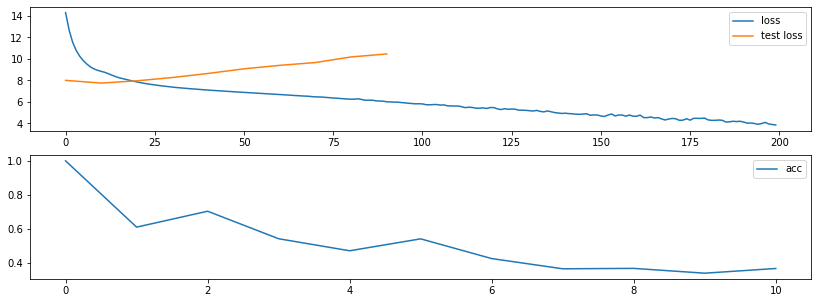

In [21]:
plt.figure(figsize=(14, 5))
axes = [plt.subplot(2, 1, i + 1) for i in range(2)]
plt.sca(axes[0])
plt.plot(losses, label='loss')
plt.plot(np.arange(len(test_losses)) * report_split, test_losses, label='test loss')
plt.legend()

plt.sca(axes[1])
plt.plot(accs, label='acc')
plt.legend()
plt.show()

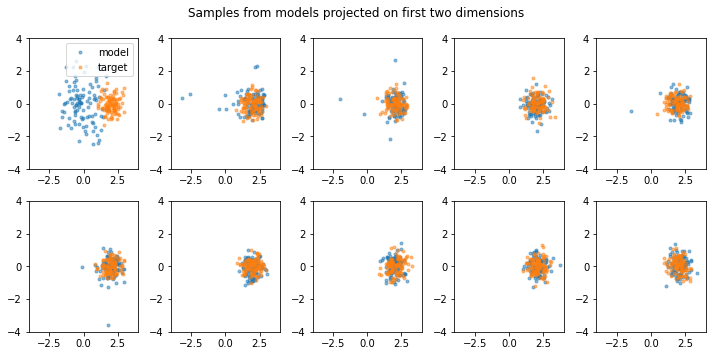

In [22]:
plt.figure(figsize=(10,5))
axes = [plt.subplot(2, 5, i + 1) for i in range(10)]
plt.suptitle('Samples from models projected on first two dimensions')
for m,model in enumerate(models[:10]):
    model.eval()
    plt.sca(axes[m])
    # set_plot(ax, prop_log_prob=model.log_prob, n_points=100)
    samples,_ = model.sample(100)
    target_samples = target.sample(100)
    plt.plot(samples[:,0].detach().numpy(), samples[:,1].detach().numpy(), '.', alpha=0.5, label='model')
    plt.plot(target_samples[:,0].detach().numpy(), target_samples[:,1].detach().numpy(), '.', alpha=0.5, label='target')
    plt.xlim(lims['x_min'], lims['x_max'])
    plt.ylim(lims['y_min'], lims['y_max'])
    if m == 0:
        plt.legend()
plt.tight_layout()
plt.show()


In [23]:
n_steps = 100
n_chains = 10

mcmc_runs = []

for model in models:
    model.eval()
    x_init = target.sample(n_chains)
    mcmc_run = run_metropolis_rqs(model, x_init, x_init.shape[0], n_steps, target.log_prob, with_tqdm=True)
    mcmc_runs.append(mcmc_run)

acc: 0.12: 100%|██████████| 100/100 [00:33<00:00,  2.96it/s]


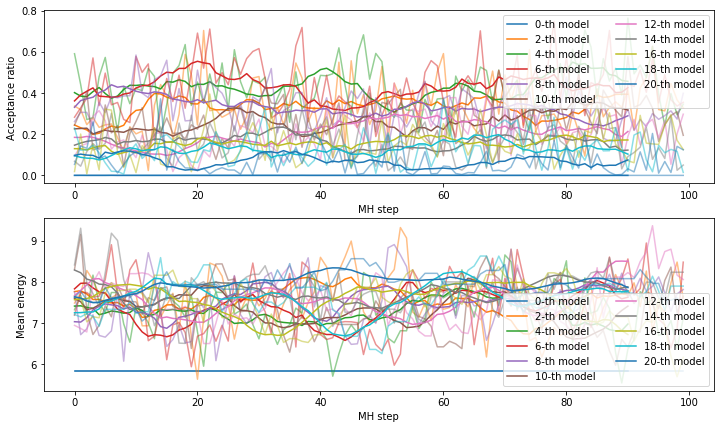

In [24]:
plt.figure(figsize=(12,7))
axes = [plt.subplot(2, 1, i + 1) for i in range(2)]
for m,mcmc_run in enumerate(mcmc_runs):
    
    xs, us, accs, nlls, ratios = mcmc_run
    plt.sca(axes[0])
    _ = plt.plot(ratios.detach().numpy(), alpha=0.5)
    plt.plot(moving_average(ratios.detach().numpy(), 10), c=_[0].get_color(), label='{:d}-th model'.format(2 * m))
    plt.xlabel('MH step')
    plt.ylabel('Acceptance ratio')
    plt.legend(ncol=2)

    plt.sca(axes[1]) 
    _ = plt.plot(us.mean(1).detach().numpy(), alpha=0.5)
    plt.plot(moving_average(us.mean(1).detach().numpy(), 10), c=_[0].get_color(), label='{:d}-th model'.format(2* m))
    plt.xlabel('MH step')
    plt.ylabel('Mean energy')
    plt.legend(ncol=2)


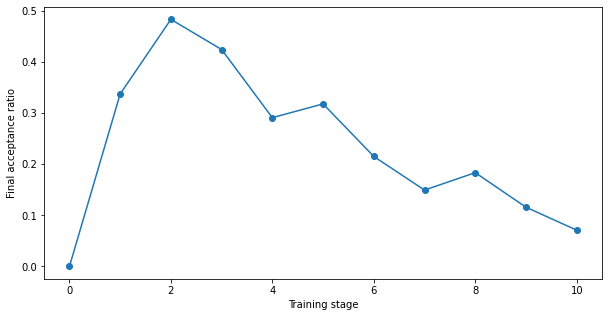

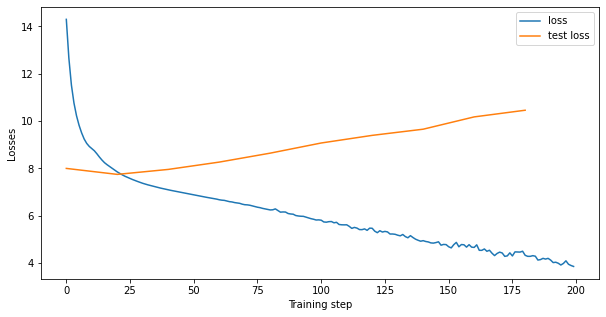

In [25]:
accs_final = []
for mcmc_run in mcmc_runs:
    xs, us, accs, nlls, ratios = mcmc_run
    accs_final.append(moving_average(ratios.detach().numpy(), 20)[-1].mean().item())
plt.figure(figsize=(10,5))
plt.plot(accs_final, '-o')
plt.xlabel('Training stage')
plt.ylabel('Final acceptance ratio')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(losses, label='loss')
plt.plot(np.arange(len(test_losses)) * 20, test_losses, label='test loss')
plt.xlabel('Training step')
plt.ylabel('Losses')
plt.legend()


So we can see the effect of over training in the acceptance rate. 

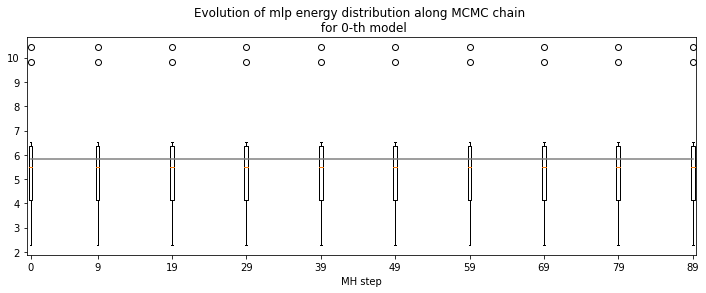

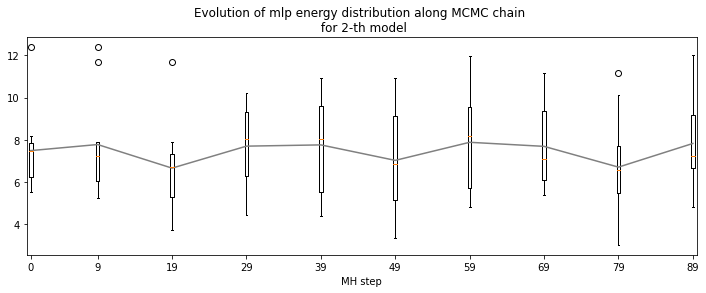

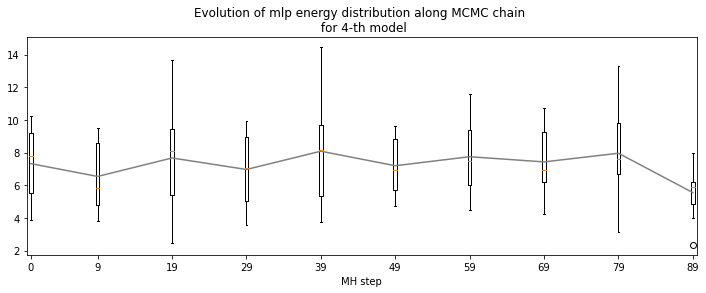

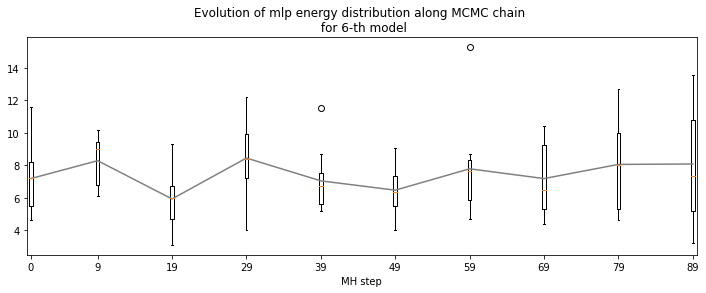

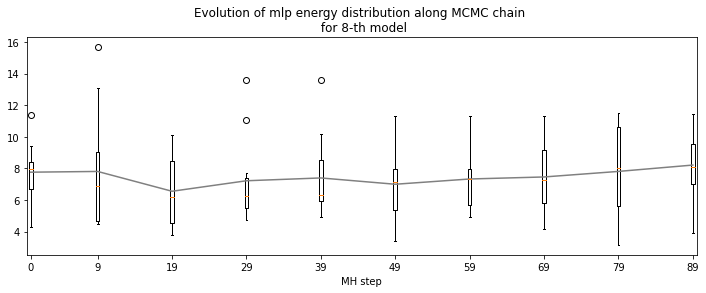

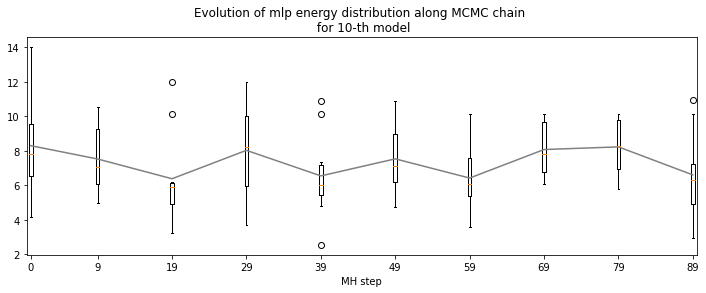

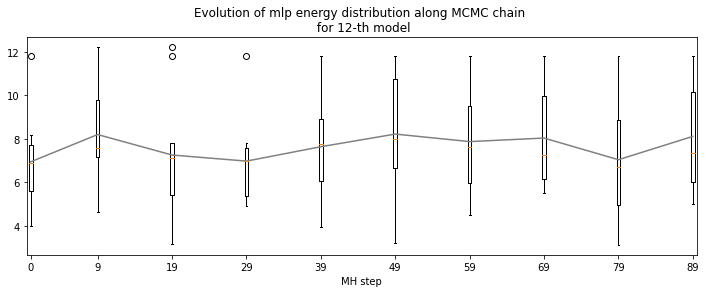

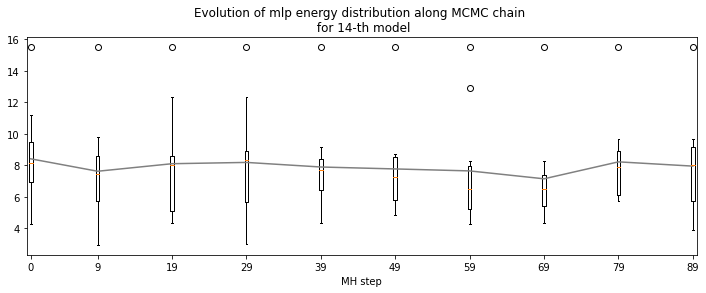

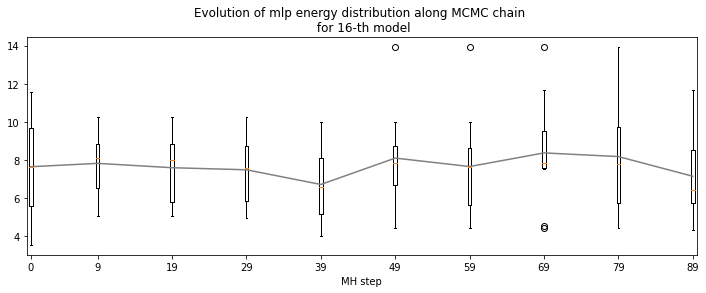

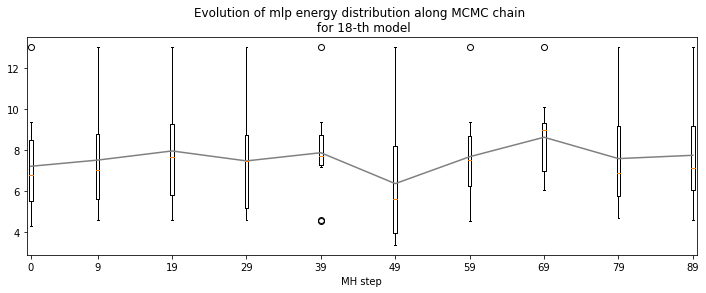

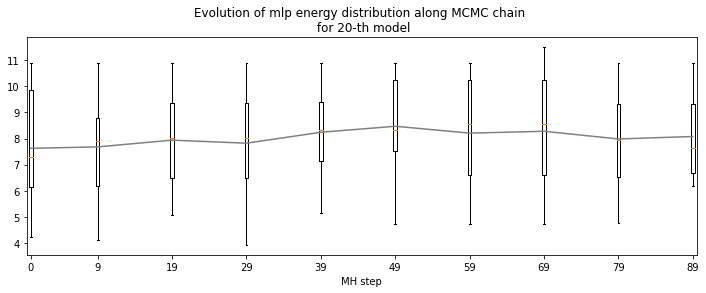

In [26]:
for m,mcmc_run in enumerate(mcmc_runs):
    xs, us, accs, nlls, ratios = mcmc_run
    plt.figure(figsize=(12,4))
    steps = np.maximum(0, np.arange(10) * 10 - 1)
    plt.boxplot([us[step, :].detach().numpy() for step in steps], positions=steps)
    plt.plot(steps, [us[step, :].detach().numpy().mean() for step in steps], '-', c='grey')
    plt.title('Evolution of mlp energy distribution along MCMC chain \n for {:d}-th model'.format(2 * m))
    plt.xlabel('MH step') 

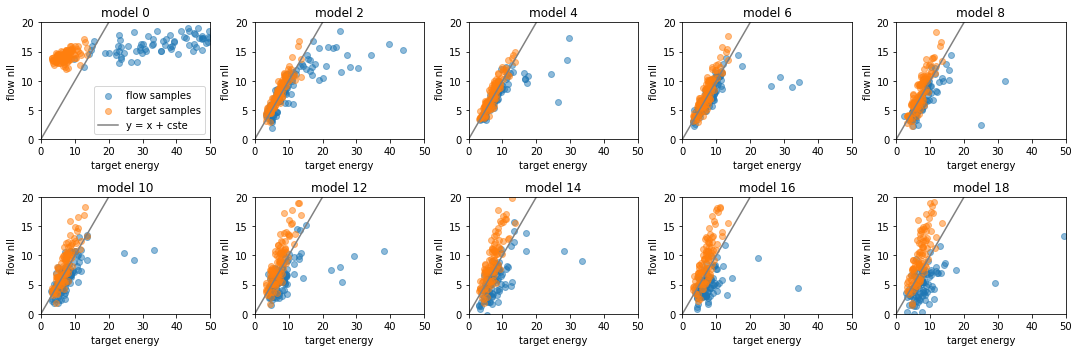

In [27]:
plt.figure(figsize=(15,5))
axes = [plt.subplot(2, 5, i + 1) for i in range(10)]
# plt.suptitle('Samples from models projected on first two dimensions')
for m,model in enumerate(models[:10]):
    model.eval()
    plt.sca(axes[m])
    final_flow = models[m]
    xs_flow_final, _ = final_flow.sample(100)

    plt.title('model {:d}'.format(2 * m))
    plt.scatter(- target.log_prob(xs_flow_final).detach().numpy(), - final_flow.log_prob(xs_flow_final).detach().numpy(), alpha=0.5, label='flow samples')
    plt.scatter(- target.log_prob(x_test[:,:12]).detach().numpy(), - final_flow.log_prob(x_test[:,:12]).detach().numpy(), alpha=0.5, label='target samples')
    plt.plot(np.arange(0, 20, 0.01), np.arange(0, 20, 0.01) - 0 , c='grey', label='y = x + cste')
    plt.ylabel('flow nll')
    plt.xlabel('target energy')
    plt.xlim(0,50)
    plt.ylim(0,20)
    if m == 0:
        plt.legend()
plt.tight_layout()
plt.show()

In [39]:
def get_participation_ratio_rqs(prop, target_log_prob, n_prop):
    """
    Compute the participation ratio of a proposal distribution

    Args:
        prop : Proposal distribution with .sample and .nll methods
        target_log_prob : Log probability of the target distribution.
        n_prop : Number of samples from the proposal distribution.
    
    Returns:
        Participation ratio, 1 if proposal is equal to target and < 1 otherwise

    """
    xs, _ = prop.sample(n_prop)
    log_weight = target_log_prob(xs).squeeze() - prop.log_prob(xs)
    log_ratio = torch.logsumexp(2 * log_weight, dim=0) - 2 * torch.logsumexp(log_weight, dim=0) 
    return torch.exp(-log_ratio) / n_prop

In [43]:
# accs_final = []
participation_ratios = []
n_prop = 5000
for (mcmc_run, model) in zip(mcmc_runs, models):
    xs, us, accs, nlls, ratios = mcmc_run
    # accs_final.append(moving_average(ratios.detach().numpy(), 20)[-1].mean().item())
    participation_ratios.append(get_participation_ratio_rqs(model, target.log_prob, n_prop).item())

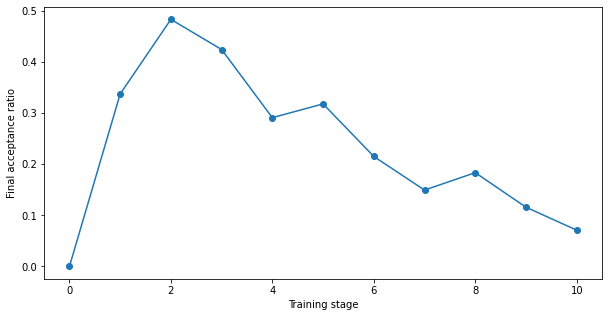

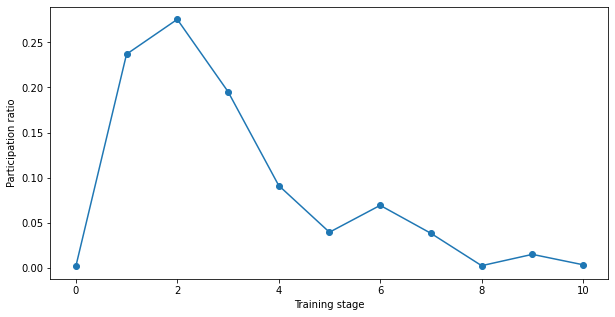

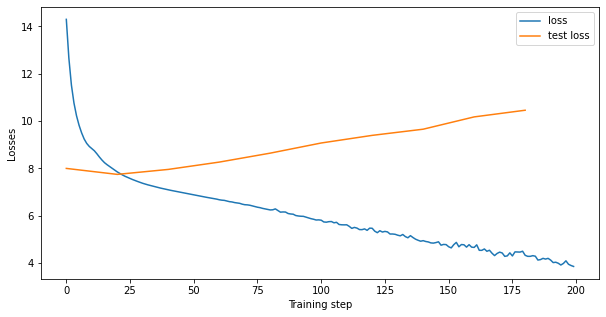

In [44]:

plt.figure(figsize=(10,5))
plt.plot(accs_final, '-o')
plt.xlabel('Training stage')
plt.ylabel('Final acceptance ratio')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(participation_ratios, '-o')
plt.xlabel('Training stage')
plt.ylabel('Participation ratio')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(losses, label='loss')
plt.plot(np.arange(len(test_losses)) * 20, test_losses, label='test loss')
plt.xlabel('Training step')
plt.ylabel('Losses')
plt.legend()